In [61]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt
import os 

In [62]:
def print_img(img) -> None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.show()

# Preprocessing

## resize

(241, 122, 3)


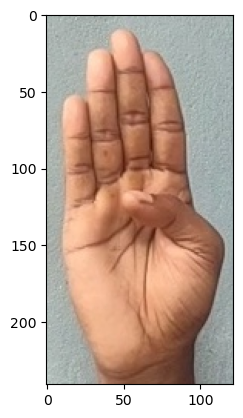

In [63]:
img = cv2.imread("../sample_data/P1_B_52.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)
plt.imshow(img_rgb)
plt.show()

(224, 113, 3)


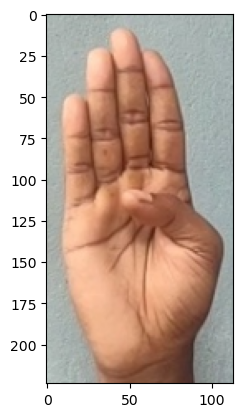

In [64]:
h, w = img.shape[:2]
size = 224
new_H, new_W = size, size
ratio = min(size / h, size /w )
new_h, new_w = int(h*ratio), int(w*ratio)
resize = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA) 

img_rgb = cv2.cvtColor(resize, cv2.COLOR_BGR2RGB)
print(img_rgb.shape)
plt.imshow(img_rgb)
plt.show()

241 122 to 224 113
(224, 113, 3) 224 113


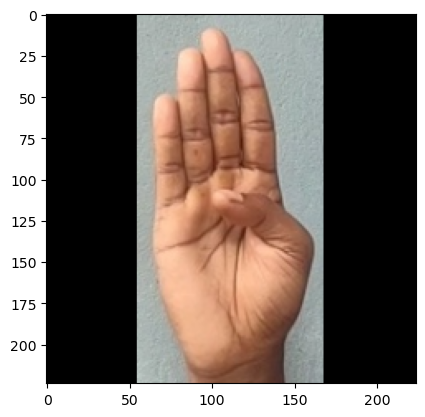

In [65]:
h, w = img.shape[:2]
size = 224
new_H, new_W = size, size
ratio = min(new_H / h, new_W / w)
new_h, new_w = int(h*ratio), int(w*ratio)
print(h,w,'to', new_h,new_w)
resize = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA) 
diff_h = (size - new_h) //2
diff_w = (size - new_w) // 2
blank_img = np.zeros((size, size, 3), dtype=np.uint8)
print(resize.shape, new_h, new_w)
blank_img[diff_h:diff_h+new_h, diff_w:diff_w+new_w] = resize
img_rgb = cv2.cvtColor(blank_img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

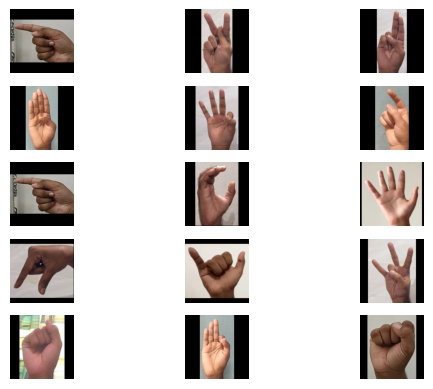

In [66]:
cwd = os.getcwd()
paths = [os.path.join(cwd, '../sample_data', i) for i in os.listdir('../sample_data')]
files = len(paths)
fix, ax = plt.subplots(5, 3)
ax = ax.flatten()
resized_files = []
i = -1 
for j, path in enumerate(paths):
    if i % 3 == 0:
        i += 1
    img = cv2.imread(path) 
    h, w = img.shape[:2]
    size = 224
    new_H, new_W = size, size
    ratio = min(new_H / h, new_W / w)
    new_h, new_w = int(h*ratio), int(w*ratio)
    resize = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA) 
    diff_h = (size - new_h) //2
    diff_w = (size - new_w) // 2
    blank_img = np.zeros((size, size, 3), dtype=np.uint8)
    blank_img[diff_h:diff_h+new_h, diff_w:diff_w+new_w] = resize
    img_rgb = cv2.cvtColor(blank_img, cv2.COLOR_BGR2RGB)
    ax[j].imshow(img_rgb)
    ax[j].axis('off')
    
plt.show()

# smoothing

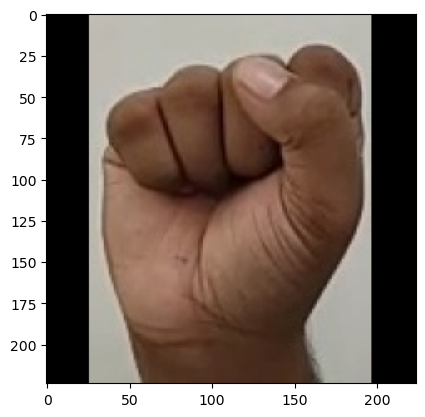

In [67]:
img1 = blank_img
print_img(img1)
blurred_img = cv2.GaussianBlur(img1, (5,5), 0)

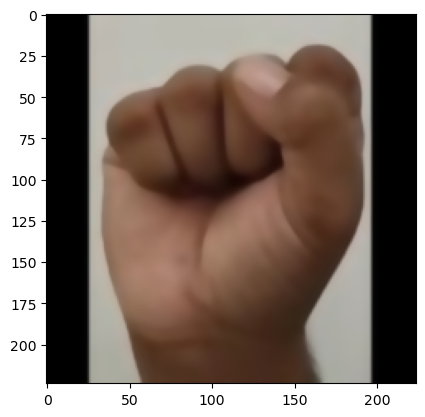

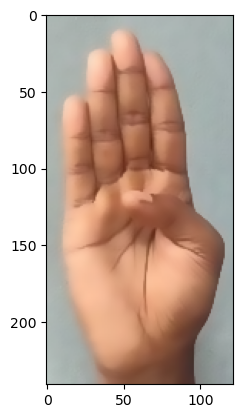

In [68]:
img1 = blurred_img 

bifilter = cv2.bilateralFilter(img1, d=9, sigmaColor=75, sigmaSpace=75)
print_img(bifilter)
img = cv2.imread("../sample_data/P1_B_52.jpg")
img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
print_img(img)



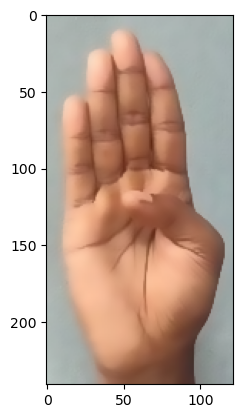

In [69]:

gamma = 1.0
inv_gamma = 1.0 / gamma
table = np.array([
    ((i / 255.0) ** inv_gamma) * 255 for i in range(256)
]).astype(np.uint8)
correct = cv2.LUT(img, table)
print_img(correct)

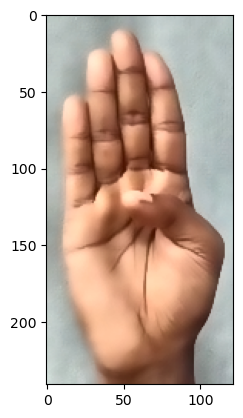

In [70]:

clip_limit = 2.0
tile_size = 8
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
l_enhanced = clahe.apply(l)
enhanced = cv2.merge([l_enhanced, a, b])
img = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
print_img(img)

# Segmentation 

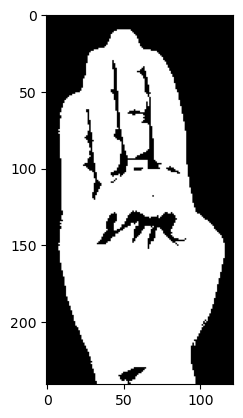

In [71]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower = np.array([0, 30, 60], dtype=np.uint8)
upper = np.array([25, 170, 255], dtype=np.uint8)
mask = cv2.inRange(hsv, lower, upper)
print_img(mask)

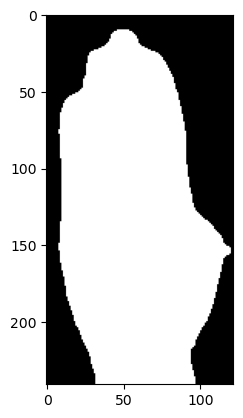

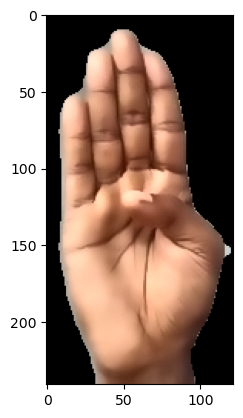

In [72]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
print_img(mask)
new = cv2.bitwise_and(img, img, mask=mask)
print_img(new)

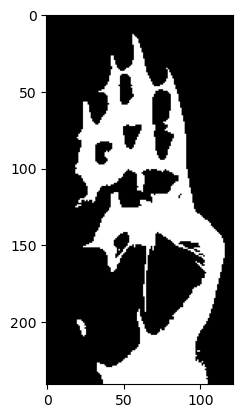

In [73]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(src=gray, thresh=0, maxval=255, type=cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
print_img(thresh)

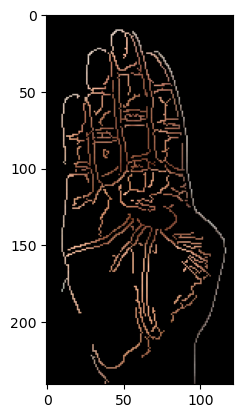

In [74]:
import cv2 as cv

max_lowThreshold = 100
window_name = 'Edge Map'
title_trackbar = 'Min Threshold:'
ratio = 3
kernel_size = 3

def CannyThreshold(src_gray, val):
    low_threshold = val
    img_blur = cv.blur(src_gray, (3,3))
    detected_edges = cv.Canny(img_blur, low_threshold, low_threshold*ratio, kernel_size)
    mask = detected_edges != 0
    dst = src * (mask[:,:,None].astype(src.dtype))
    return dst

src = cv.imread('../sample_data/P1_B_52.jpg')

src_gray = cv.cvtColor(src, cv.COLOR_BGR2GRAY)

print_img(CannyThreshold(src_gray, 35))

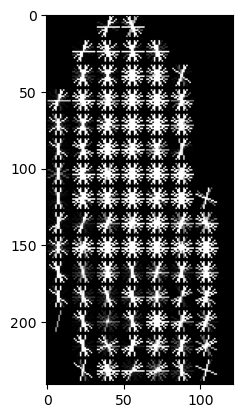

In [77]:
from skimage.feature import hog
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.bitwise_and(gray, gray, mask=mask)
feats, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(16,16),
    cells_per_block=(2,2),
    block_norm='L2-Hys',
    feature_vector=True,
    visualize=True,
)

hog_image = (hog_image * 255).clip(0, 255).astype(np.uint8)
print_img(hog_image)